# 01 · Exploración inicial

**Pregunta que responde este notebook:** ¿con qué estamos trabajando, y hay algo
que impida modelar directamente?

El objetivo no es hacer gráficos, es tomar decisiones. Cada sección termina con
una conclusión explícita, y la última celda recoge todas las que afectan a la
Fase 3 (feature engineering y entrenamiento).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[1]))

import pandas as pd

from src.config import CATEGORICAL_FEATURES, NUMERIC_FEATURES, TARGET
from src.data.generate_data import load_raw, regime_for
from src.viz import SERIES, STATUS, plt, save_figure, set_style

set_style()
pd.set_option("display.width", 120)

df = load_raw()
print(f"{len(df):,} filas · {df.shape[1]} columnas · {df.snapshot_month.nunique()} meses")

48,824 filas · 17 columnas · 18 meses


## Forma y tipos

18 snapshots mensuales de la base de clientes activos. Cada fila es un cliente
en un mes concreto, y `churn` indica si se dio de baja durante ese mes.

Un detalle que condiciona todo lo que viene después: **`customer_id` se repite
entre meses**, porque un cliente que no abandona sigue apareciendo el mes
siguiente. No es un duplicado, es un panel de datos. Confundir ambas cosas
llevaría a "limpiar" filas legítimas.

In [2]:
df.head()

,customer_id,snapshot_month,age,gender,region,senior_citizen,contract_type,tenure_months,monthly_charges,payment_method,paperless_billing,monthly_usage_gb,support_tickets_30d,avg_session_minutes,num_services,late_payments_3m,churn
0,CUST-000001,2024-01,69,M,Norte,No,One year,2,52.60,Mailed check,Yes,8.53,1,29.4,4,0,0
1,CUST-000002,2024-01,53,M,Centro,No,Month-to-month,21,58.55,Bank transfer,Yes,7.68,1,18.0,4,0,0
2,CUST-000003,2024-01,55,F,Norte,No,Two year,23,75.22,Credit card,No,7.07,1,7.1,5,1,0
3,CUST-000004,2024-01,18,M,Occidente,No,One year,16,82.48,Bank transfer,Yes,17.01,3,38.0,2,1,0
4,CUST-000005,2024-01,44,F,Norte,No,Month-to-month,14,56.62,Bank transfer,Yes,8.79,2,40.7,5,0,0


In [3]:
df.dtypes.to_frame("tipo").T

,customer_id,snapshot_month,age,gender,region,senior_citizen,contract_type,tenure_months,monthly_charges,payment_method,paperless_billing,monthly_usage_gb,support_tickets_30d,avg_session_minutes,num_services,late_payments_3m,churn
tipo,object,object,int64,object,object,object,object,int64,float64,object,object,float64,int64,float64,int64,int64,int64


## Nulos y duplicados

In [4]:
nulos = df.isna().sum()
print("Valores nulos por columna:")
print(nulos[nulos > 0] if nulos.any() else "  ninguno")

filas_dup = df.duplicated().sum()
id_mes_dup = df.duplicated(subset=["customer_id", "snapshot_month"]).sum()
clientes_multi_mes = (df.groupby("customer_id").size() > 1).sum()

print(f"\nFilas completamente duplicadas:            {filas_dup}")
print(f"Duplicados de (customer_id, snapshot_month): {id_mes_dup}")
print(f"Clientes presentes en más de un mes:         {clientes_multi_mes:,}")

Valores nulos por columna:
  ninguno

Filas completamente duplicadas:            0
Duplicados de (customer_id, snapshot_month): 0
Clientes presentes en más de un mes:         7,728


> **Conclusión.** No hay nulos ni duplicados reales. La clave del panel es el
> par `(customer_id, snapshot_month)`, que sí es único. Los ~40.000 clientes que
> aparecen en varios meses son la estructura del dataset, no un error.
>
> **Decisión para la Fase 3:** `customer_id` se excluye de las features. Es un
> identificador; incluirlo permitiría al modelo memorizar clientes concretos y
> además provocaría fuga entre train y validación, porque el mismo cliente vive
> en ambos periodos.

## Distribución de la variable objetivo

Esta es la cifra que más decisiones condiciona en todo el proyecto.

figura guardada: docs/img/01_desbalance_churn.png

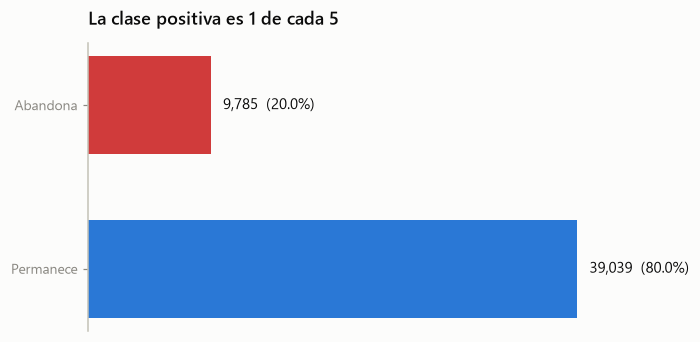

Tasa global de churn: 20.04%  ·  ratio 4.0 a 1


In [5]:
conteo = df[TARGET].value_counts().sort_index()
tasa = df[TARGET].mean()

fig, ax = plt.subplots(figsize=(7, 3.4))
barras = ax.barh(
    ["Permanece", "Abandona"],
    [conteo[0], conteo[1]],
    color=[SERIES[0], STATUS["critical"]],
    height=0.6,
)
for barra, valor in zip(barras, [conteo[0], conteo[1]], strict=True):
    ax.annotate(
        f"{valor:,}  ({valor / len(df):.1%})",
        xy=(barra.get_width(), barra.get_y() + barra.get_height() / 2),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        fontsize=10,
        color="#0b0b0b",
    )
ax.set_title("La clase positiva es 1 de cada 5")
ax.set_xlim(0, conteo.max() * 1.22)
ax.grid(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(bottom=False, labelbottom=False)
save_figure(fig, "01_desbalance_churn")
plt.show()

print(f"Tasa global de churn: {tasa:.2%}  ·  ratio {(1 - tasa) / tasa:.1f} a 1")

> **Conclusión.** Desbalance de ~80/20. No es extremo, pero sí suficiente para
> que la *accuracy* sea una métrica inútil: un modelo que prediga siempre
> "permanece" acierta el 80 % de las veces y no sirve para nada.
>
> **Decisiones para la Fase 3:**
> - Métrica principal **AUC-ROC**, y **PR-AUC** como segunda, porque la
>   precision-recall es más sensible al rendimiento sobre la clase minoritaria.
> - `class_weight="balanced"` en la regresión logística y `scale_pos_weight` en
>   los modelos de gradient boosting.
> - Reportar precision y recall por separado, nunca solo accuracy.

## Volumen y tasa de churn por mes

Antes de mirar ninguna variable, conviene comprobar que los 18 meses son
comparables entre sí. Si el tamaño de la base o la tasa base de churn variaran
mucho, cualquier comparación temporal posterior estaría contaminada.

In [6]:
por_mes = (
    df.groupby("snapshot_month")
    .agg(clientes=(TARGET, "size"), tasa_churn=(TARGET, "mean"))
    .reset_index()
)
por_mes["regimen"] = [regime_for(i) for i in range(len(por_mes))]
por_mes

,snapshot_month,clientes,tasa_churn,regimen
0,2024-01,2500,0.202800,baseline
1,2024-02,2525,0.196040,baseline
2,2024-03,2550,0.201961,baseline
3,2024-04,2575,0.191068,baseline
4,2024-05,2600,0.200769,baseline
5,2024-06,2625,0.201524,baseline
6,2024-07,2650,0.200755,baseline
7,2024-08,2675,0.215327,baseline
8,2024-09,2700,0.198519,data_drift
9,2024-10,2725,0.197431,data_drift


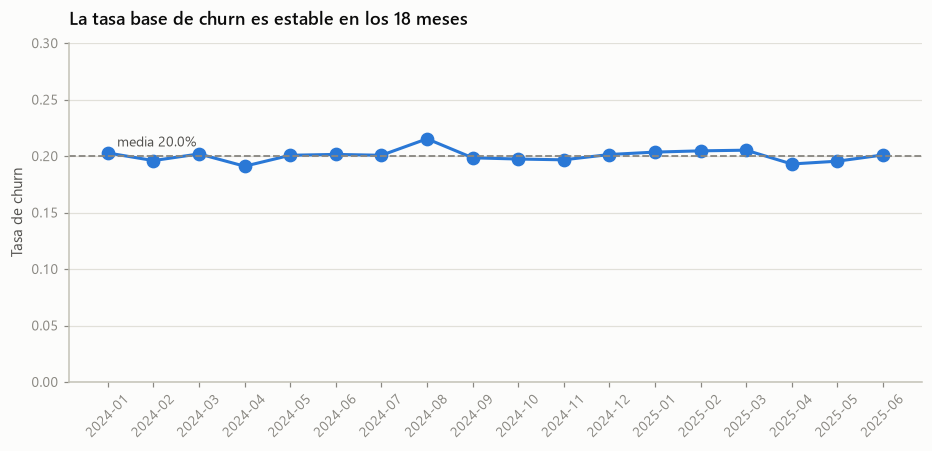

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(por_mes.snapshot_month, por_mes.tasa_churn, marker="o", color=SERIES[0])
ax.axhline(tasa, color="#898781", linestyle="--", linewidth=1.2)
ax.annotate(
    f"media {tasa:.1%}",
    xy=(0.2, tasa),
    xytext=(0, 6),
    textcoords="offset points",
    fontsize=9,
    color="#52514e",
)
ax.set_ylim(0, 0.30)
ax.set_ylabel("Tasa de churn")
ax.set_title("La tasa base de churn es estable en los 18 meses")
ax.tick_params(axis="x", rotation=45)
plt.show()

> **Conclusión.** El tamaño de la base crece un ~17 % en 18 meses y la tasa de
> churn se mueve entre el 19 % y el 21,5 %, sin tendencia. Los meses son
> comparables.
>
> Esto importa más de lo que parece: significa que **si más adelante el modelo
> empeora, no va a ser porque "se vaya menos gente"**. La tasa base está fija, así
> que cualquier degradación tendrá que venir de un cambio en la relación entre
> las variables y el objetivo. Es lo que permite atribuir causas en la Fase 8.

## Resumen numérico

In [8]:
df[NUMERIC_FEATURES].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,48824.0,44.65,14.44,18.00,34.00,44.00,55.00,92.00
tenure_months,48824.0,18.31,21.81,0.00,2.00,6.00,36.00,76.00
monthly_charges,48824.0,58.28,24.01,18.00,40.59,57.40,74.57,166.56
monthly_usage_gb,48824.0,15.93,8.76,0.26,9.81,14.01,19.98,133.01
support_tickets_30d,48824.0,0.90,0.97,0.00,0.00,1.00,1.00,7.00
avg_session_minutes,48824.0,30.55,10.44,1.00,23.50,30.40,37.50,74.30
num_services,48824.0,3.69,1.61,1.00,2.00,4.00,5.00,8.00
late_payments_3m,48824.0,0.40,0.66,0.00,0.00,0.00,1.00,6.00


In [9]:
for col in CATEGORICAL_FEATURES:
    print(f"{col:>20}: {df[col].nunique()} valores → {sorted(df[col].unique())}")

              gender: 2 valores → ['F', 'M']
              region: 4 valores → ['Centro', 'Norte', 'Occidente', 'Sur']
      senior_citizen: 2 valores → ['No', 'Yes']
       contract_type: 3 valores → ['Month-to-month', 'One year', 'Two year']
      payment_method: 4 valores → ['Bank transfer', 'Credit card', 'Electronic check', 'Mailed check']
   paperless_billing: 2 valores → ['No', 'Yes']


---
## Conclusiones de este notebook

| Hallazgo | Decisión para la Fase 3 |
|---|---|
| Sin nulos ni duplicados reales | No hace falta imputación por ausencia de datos, pero el pipeline la incluirá igualmente para ser robusto ante datos nuevos en producción |
| Panel: un cliente aparece en varios meses | Excluir `customer_id` de las features y **partir por tiempo, no aleatoriamente**, para evitar fuga del mismo cliente entre train y validación |
| Desbalance 80/20 | AUC-ROC y PR-AUC como métricas; `class_weight`/`scale_pos_weight` |
| Tasa base estable mes a mes | Cualquier caída futura de rendimiento será atribuible a un cambio de relación, no de prevalencia |

**Siguiente:** `02_analisis_univariado.ipynb` — cómo se distribuye cada variable
por separado y qué hay que corregir antes de modelar.